### TOTAL CONTACTS

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_2113/1372416224.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


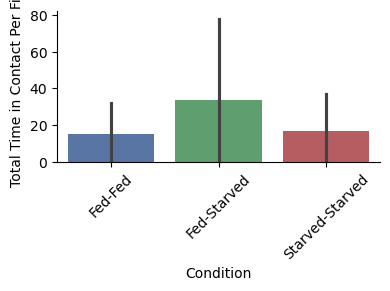

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/closest_contacts_1mm.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/closest_contacts_1mm.csv')
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/closest_contacts_1mm.csv')
df3['Condition'] = 'Starved-Starved'


df = pd.concat([df1, df2, df3], ignore_index=True)

contacts_per_file = (
    df.groupby(['Condition', 'file'])['frame']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='total_contacts')
)

order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
palette = {
    "Fed-Fed": "#4C72B0",
    "Fed-Starved": "#55A868",
    "Starved-Starved": "#C44E52",
}


plt.figure(figsize=(4,3))

sns.barplot(
    data=contacts_per_file,
    x='Condition',
    y='total_contacts', order = order, palette=palette, errorbar='sd'
)

plt.xticks(rotation=45)
plt.ylim(0, None)
plt.ylabel('Total Time in Contact Per File')
plt.xlabel('Condition')
sns.despine()

plt.tight_layout()
# plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/total-contact.pdf', format='pdf')
plt.show()

In [2]:
from scipy.stats import mannwhitneyu

comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

results = []

for group_1, group_2 in comparisons:
    values_1 = contacts_per_file.loc[
        contacts_per_file['Condition'] == group_1,
        'total_contacts'
    ]
    values_2 = contacts_per_file.loc[
        contacts_per_file['Condition'] == group_2,
        'total_contacts'
    ]

    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

    results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'Mann-Whitney U': stat,
        'p value': p_value,
    })

mann_whitney_results = pd.DataFrame(results)
mann_whitney_results


,Comparison,Mann-Whitney U,p value
0,Fed-Fed vs Fed-Starved,273.0,0.115928
1,Fed-Starved vs Starved-Starved,334.5,0.257053


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_2113/1604041605.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


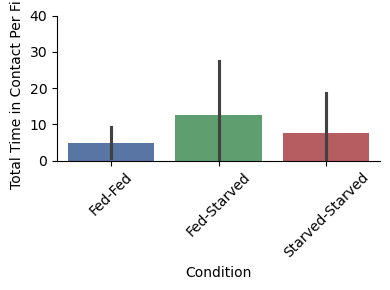

In [3]:
df = df[df['Closest Interaction Type'] == 'head_head']


contacts_per_file = (
    df.groupby(['Condition', 'file'])['frame']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='total_contacts')
)

plt.figure(figsize=(4, 3))

sns.barplot(
    data=contacts_per_file,
    x='Condition',
    y='total_contacts', order = order, palette=palette, errorbar='sd'
)

plt.xticks(rotation=45)
plt.ylim(0, 40)
plt.ylabel('Total Time in Contact Per File')
plt.xlabel('Condition')
sns.despine()

plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/total-contact-head.pdf', format='pdf')
plt.show()



In [4]:
from scipy.stats import mannwhitneyu

comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

results = []

for group_1, group_2 in comparisons:
    values_1 = contacts_per_file.loc[
        contacts_per_file['Condition'] == group_1,
        'total_contacts'
    ]
    values_2 = contacts_per_file.loc[
        contacts_per_file['Condition'] == group_2,
        'total_contacts'
    ]

    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

    results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'Mann-Whitney U': stat,
        'p value': p_value,
    })

mann_whitney_results = pd.DataFrame(results)
mann_whitney_results


,Comparison,Mann-Whitney U,p value
0,Fed-Fed vs Fed-Starved,129.0,0.091833
1,Fed-Starved vs Starved-Starved,165.0,0.147349


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_2113/1986734475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


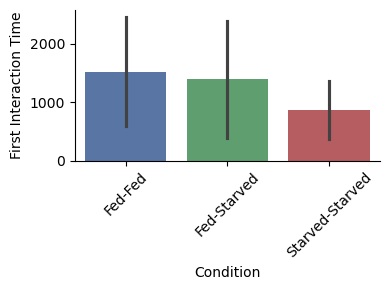

In [5]:
first_interaction_per_file = (
    df.dropna(subset=['frame'])
      .groupby(['Condition', 'file'], as_index=False)['frame']
      .min()
      .rename(columns={'frame': 'first_interaction_frame'})
)
first_interaction_per_file['first_interaction_time'] = first_interaction_per_file['first_interaction_frame']
plt.figure(figsize=(4, 3))

sns.barplot(
    data=first_interaction_per_file,
    x='Condition',
    y='first_interaction_time', order=order, palette=palette, errorbar='sd'
)

plt.xticks(rotation=45)
plt.ylim(0, None)
plt.ylabel('First Interaction Time')
plt.xlabel('Condition')
sns.despine()

plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/first-interaction-time-head.pdf', format='pdf')
plt.show()


In [6]:
from scipy.stats import mannwhitneyu

comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

results = []

for group_1, group_2 in comparisons:
    values_1 = first_interaction_per_file.loc[
        first_interaction_per_file['Condition'] == group_1,
        'first_interaction_time'
    ]
    values_2 = first_interaction_per_file.loc[
        first_interaction_per_file['Condition'] == group_2,
        'first_interaction_time'
    ]

    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')
    significance = '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'Mann-Whitney U': stat,
        'p value': p_value,
        'Significance': significance,
    })

first_interaction_mann_whitney_results = pd.DataFrame(results)
print(first_interaction_mann_whitney_results[['Comparison', 'Significance']].to_string(index=False))
first_interaction_mann_whitney_results


                    Comparison Significance
        Fed-Fed vs Fed-Starved           ns
Fed-Starved vs Starved-Starved           ns


,Comparison,Mann-Whitney U,p value,Significance
0,Fed-Fed vs Fed-Starved,208.0,0.602242,ns
1,Fed-Starved vs Starved-Starved,157.0,0.253689,ns


### INTERACTION BOUTS

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'Starved-Starved'

df = pd.concat([df1, df2, df3], ignore_index=True)

df['interaction_number'] = (
    df.groupby(['Condition', 'file']).cumcount() + 1
)

order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
palette = {
    "Fed-Fed": "#4C72B0",
    "Fed-Starved": "#55A868",
    "Starved-Starved": "#C44E52",
}


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_2113/649470812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


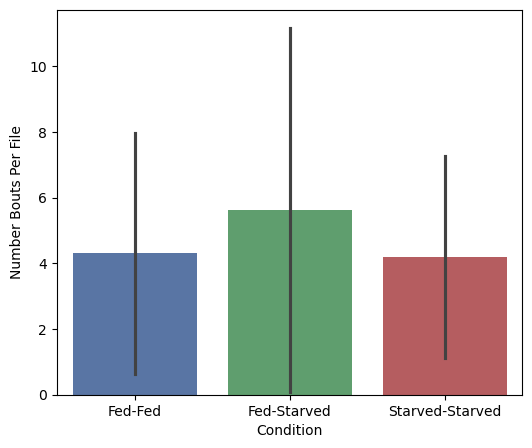

In [8]:
bout_counts = (
    df.groupby(['Condition', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=bout_counts,
    x='Condition',
    y='n_bouts', order = order, palette=palette, errorbar='sd'
)       

plt.ylim(0, None)
plt.ylabel('Number Bouts Per File')
plt.xlabel('Condition')
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_2113/3975830783.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


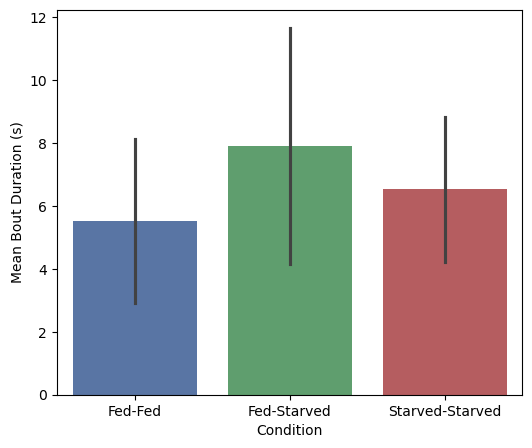

In [9]:
duration_per_file = (
    df.groupby(['Condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)


plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration', order = order, palette=palette, errorbar='sd'
)       

plt.ylim(0, None)
plt.ylabel('Mean Bout Duration (s)')
plt.xlabel('Condition')
plt.show()

In [10]:
from scipy.stats import mannwhitneyu

duration_comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

duration_results = []

for group_1, group_2 in duration_comparisons:
    values_1 = duration_per_file.loc[
        duration_per_file['Condition'] == group_1,
        'mean_bout_duration'
    ]
    values_2 = duration_per_file.loc[
        duration_per_file['Condition'] == group_2,
        'mean_bout_duration'
    ]

    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

    duration_results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'Mann-Whitney U': stat,
        'p value': p_value,
    })

duration_mann_whitney_results = pd.DataFrame(duration_results)
duration_mann_whitney_results


,Comparison,Mann-Whitney U,p value
0,Fed-Fed vs Fed-Starved,143.0,0.022848
1,Fed-Starved vs Starved-Starved,218.5,0.272414


### SPECIFICALLY HEAD-HEAD CONTACTS

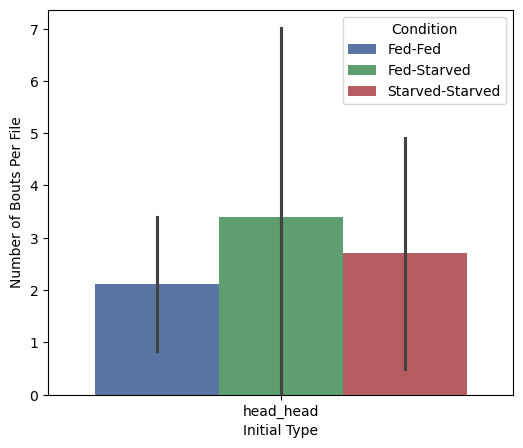

In [11]:
df = df[df["initial_type"] == "head_head"]

counts = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=counts,
    x='initial_type',
    hue = 'Condition',
    y='count',  palette=palette, errorbar='sd'
)

plt.ylim(0, None)
plt.ylabel('Number of Bouts Per File')
plt.xlabel('Initial Type')
plt.show()

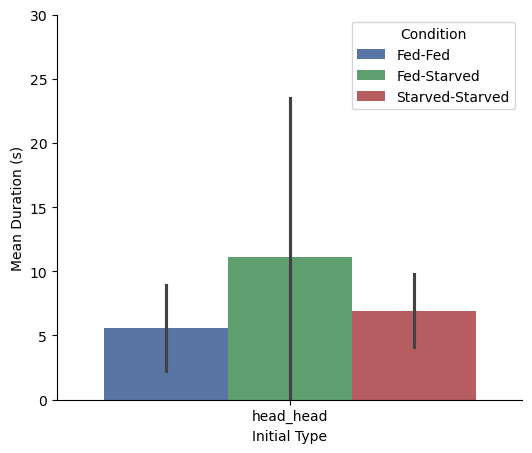

In [12]:
duration_by_type = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_by_type,
    x='initial_type',
    hue='Condition',
    y='duration', palette=palette, errorbar='sd'
)

plt.ylim(0, 30)
plt.ylabel('Mean Duration (s)')
plt.xlabel('Initial Type')
sns.despine()


plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/mean-head-duration.pdf', format='pdf')
plt.show()

In [13]:
from scipy.stats import mannwhitneyu

duration_by_type_comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

duration_by_type_results = []

for initial_type in duration_by_type['initial_type'].dropna().unique():
    type_data = duration_by_type[duration_by_type['initial_type'] == initial_type]

    for group_1, group_2 in duration_by_type_comparisons:
        values_1 = type_data.loc[
            type_data['Condition'] == group_1,
            'duration'
        ]
        values_2 = type_data.loc[
            type_data['Condition'] == group_2,
            'duration'
        ]

        stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

        duration_by_type_results.append({
            'Initial Type': initial_type,
            'Comparison': f'{group_1} vs {group_2}',
            'Mann-Whitney U': stat,
            'p value': p_value,
        })

duration_by_type_mann_whitney_results = pd.DataFrame(duration_by_type_results)
duration_by_type_mann_whitney_results


,Initial Type,Comparison,Mann-Whitney U,p value
0,head_head,Fed-Fed vs Fed-Starved,105.5,0.030119
1,head_head,Fed-Starved vs Starved-Starved,130.0,0.193751


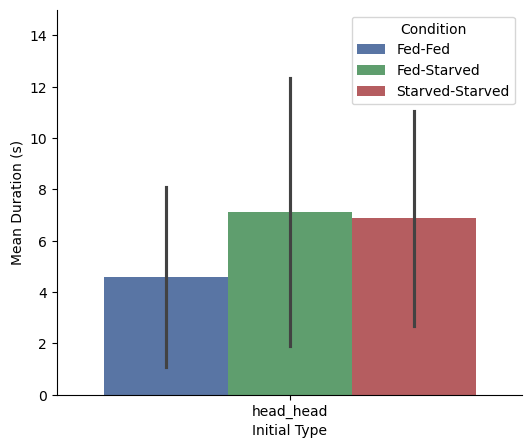

In [14]:

df_20mins = df[df['start_frame'] < 1200]
df_20mins = df_20mins[df_20mins['interaction_number'] == 1]


duration_by_type = (
    df_20mins.groupby(['Condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_by_type,
    x='initial_type',
    hue='Condition',
    y='duration', palette=palette, errorbar='sd'
)

plt.ylim(0, 15)
plt.ylabel('Mean Duration (s)')
plt.xlabel('Initial Type')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/mean-head-duration-20-mins.pdf', format='pdf')
plt.show()

In [15]:
from scipy.stats import mannwhitneyu

filtered_duration_by_type_comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

filtered_duration_by_type_results = []

for initial_type in duration_by_type['initial_type'].dropna().unique():
    type_data = duration_by_type[duration_by_type['initial_type'] == initial_type]

    for group_1, group_2 in filtered_duration_by_type_comparisons:
        values_1 = type_data.loc[
            type_data['Condition'] == group_1,
            'duration'
        ]
        values_2 = type_data.loc[
            type_data['Condition'] == group_2,
            'duration'
        ]

        stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

        filtered_duration_by_type_results.append({
            'Initial Type': initial_type,
            'Comparison': f'{group_1} vs {group_2}',
            'Mann-Whitney U': stat,
            'p value': p_value,
        })

filtered_duration_by_type_mann_whitney_results = pd.DataFrame(filtered_duration_by_type_results)
filtered_duration_by_type_mann_whitney_results


,Initial Type,Comparison,Mann-Whitney U,p value
0,head_head,Fed-Fed vs Fed-Starved,25.0,0.523212
1,head_head,Fed-Starved vs Starved-Starved,36.5,1.000000


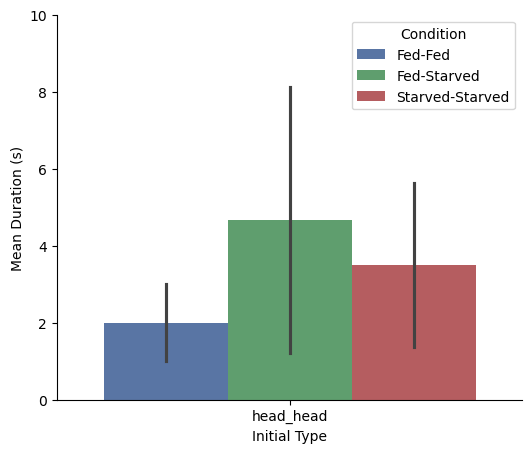

In [16]:

df_10mins = df[df['start_frame'] < 600]
df_10mins = df_10mins[df_10mins['interaction_number'] == 1]


duration_by_type = (
    df_10mins.groupby(['Condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_by_type,
    x='initial_type',
    hue='Condition',
    y='duration', palette=palette, errorbar='sd'
)

plt.ylim(0, 10)
plt.ylabel('Mean Duration (s)')
plt.xlabel('Initial Type')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/mean-head-duration-10-mins.pdf', format='pdf')
plt.show()

In [17]:
from scipy.stats import mannwhitneyu

filtered_duration_by_type_comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

filtered_duration_by_type_results = []

for initial_type in duration_by_type['initial_type'].dropna().unique():
    type_data = duration_by_type[duration_by_type['initial_type'] == initial_type]

    for group_1, group_2 in filtered_duration_by_type_comparisons:
        values_1 = type_data.loc[
            type_data['Condition'] == group_1,
            'duration'
        ]
        values_2 = type_data.loc[
            type_data['Condition'] == group_2,
            'duration'
        ]

        stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

        filtered_duration_by_type_results.append({
            'Initial Type': initial_type,
            'Comparison': f'{group_1} vs {group_2}',
            'Mann-Whitney U': stat,
            'p value': p_value,
        })

filtered_duration_by_type_mann_whitney_results = pd.DataFrame(filtered_duration_by_type_results)
filtered_duration_by_type_mann_whitney_results


,Initial Type,Comparison,Mann-Whitney U,p value
0,head_head,Fed-Fed vs Fed-Starved,5.5,0.428794
1,head_head,Fed-Starved vs Starved-Starved,7.0,0.864395


### HEAD-HEAD BOUTS ACROSS TIME BINS


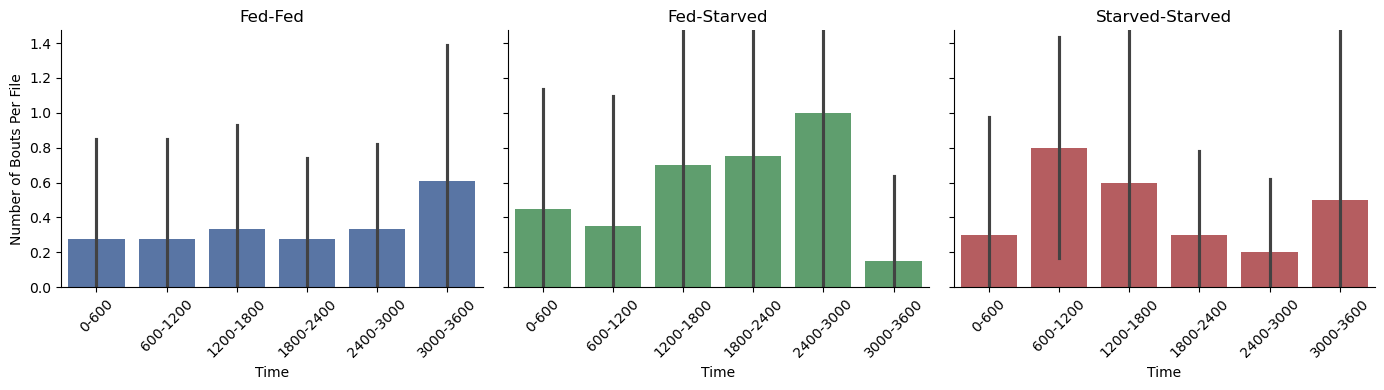

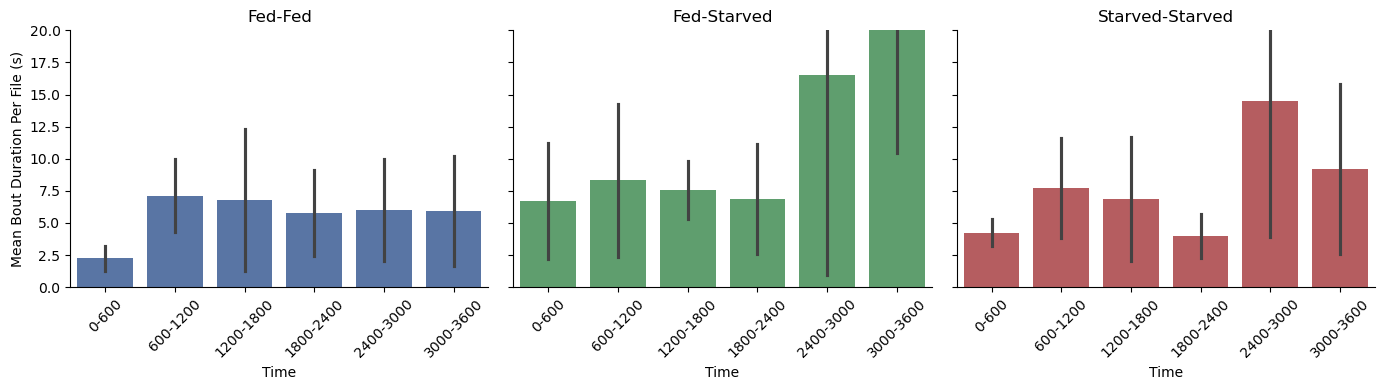

In [18]:
# Reload the bout data so this section uses all head-head bouts, not the filtered first-interaction df above.
head_head_df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
head_head_df1['Condition'] = 'Fed-Fed'

head_head_df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
head_head_df2['Condition'] = 'Fed-Starved'

head_head_df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
head_head_df3['Condition'] = 'Starved-Starved'

head_head_time_df = pd.concat([head_head_df1, head_head_df2, head_head_df3], ignore_index=True)
head_head_time_df = head_head_time_df[head_head_time_df['initial_type'] == 'head_head'].copy()

bin_edges = np.arange(0, 3600 + 600, 600)
bin_labels = [f'{start}-{end}' for start, end in zip(bin_edges[:-1], bin_edges[1:])]

head_head_time_df = head_head_time_df[
    (head_head_time_df['start_frame'] >= bin_edges[0]) &
    (head_head_time_df['start_frame'] < bin_edges[-1])
].copy()

head_head_time_df['time_bin'] = (
    pd.cut(
        head_head_time_df['start_frame'],
        bins=bin_edges,
        labels=bin_labels,
        right=False,
        include_lowest=True,
    )
    .astype(str)
)

bout_counts_by_file_time = (
    head_head_time_df.groupby(['Condition', 'file', 'time_bin'], observed=False)
      .size()
      .rename('n_bouts')
)

all_condition_files = head_head_time_df[['Condition', 'file']].drop_duplicates()
all_count_bins = pd.MultiIndex.from_frame(
    all_condition_files.assign(_key=1)
      .merge(pd.DataFrame({'time_bin': bin_labels, '_key': 1}), on='_key')
      .drop(columns='_key')
)

bout_counts_by_file_time = (
    bout_counts_by_file_time.reindex(all_count_bins, fill_value=0)
      .reset_index()
)

bout_duration_by_file_time = (
    head_head_time_df.groupby(['Condition', 'file', 'time_bin'], observed=False)['duration']
      .mean()
      .reset_index(name='mean_bout_duration')
)

fig, axes = plt.subplots(1, len(order), figsize=(14, 4), sharey=True)

for ax, condition in zip(axes, order):
    condition_counts = bout_counts_by_file_time[bout_counts_by_file_time['Condition'] == condition]

    sns.barplot(
        data=condition_counts,
        x='time_bin',
        y='n_bouts',
        order=bin_labels,
        color=palette[condition],
        errorbar='sd',
        ax=ax,
    )

    ax.set_title(condition)
    ax.set_xlabel('Time')
    ax.set_ylabel('Number of Bouts Per File' if condition == order[0] else '')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, None)

sns.despine()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(order), figsize=(14, 4), sharey=True)

for ax, condition in zip(axes, order):
    condition_durations = bout_duration_by_file_time[bout_duration_by_file_time['Condition'] == condition]

    sns.barplot(
        data=condition_durations,
        x='time_bin',
        y='mean_bout_duration',
        order=bin_labels,
        color=palette[condition],
        errorbar='sd',
        ax=ax,
    )

    ax.set_title(condition)
    ax.set_xlabel('Time')
    ax.set_ylabel('Mean Bout Duration Per File (s)' if condition == order[0] else '')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 20)

sns.despine()
plt.tight_layout()
plt.show()


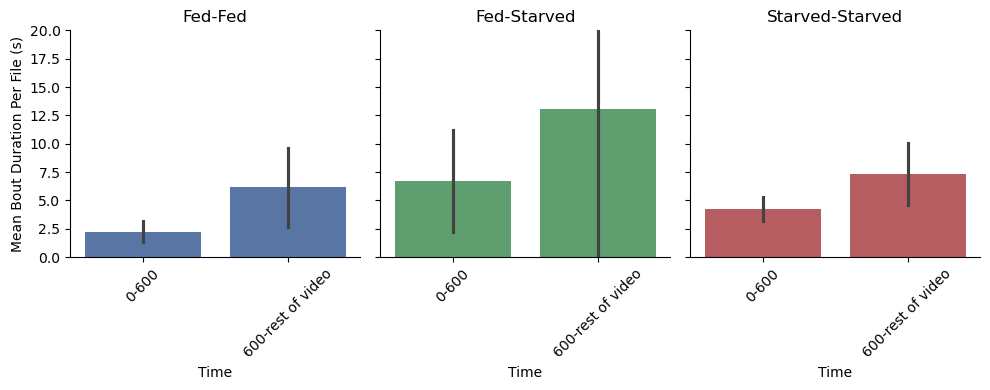

In [ ]:
# Head-head bout duration split into 0-600 and the rest of the video.
head_head_rest_df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
head_head_rest_df1['Condition'] = 'Fed-Fed'

head_head_rest_df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
head_head_rest_df2['Condition'] = 'Fed-Starved'

head_head_rest_df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
head_head_rest_df3['Condition'] = 'Starved-Starved'

head_head_rest_df = pd.concat([head_head_rest_df1, head_head_rest_df2, head_head_rest_df3], ignore_index=True)
head_head_rest_df = head_head_rest_df[head_head_rest_df['initial_type'] == 'head_head'].copy()

head_head_rest_df['time_bin'] = np.where(
    head_head_rest_df['start_frame'] < 1200,
    '0-1200',
    '1200-rest of video',
)

duration_0_600_rest = (
    head_head_rest_df.groupby(['Condition', 'file', 'time_bin'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

fig, axes = plt.subplots(1, len(order), figsize=(10, 4), sharey=True)

for ax, condition in zip(axes, order):
    condition_durations = duration_0_600_rest[duration_0_600_rest['Condition'] == condition]

    sns.barplot(
        data=condition_durations,
        x='time_bin',
        y='mean_bout_duration',
        order=['0-600', '600-rest of video'],
        color=palette[condition],
        errorbar='sd',
        ax=ax,
    )

    ax.set_title(condition)
    ax.set_xlabel('Time')
    ax.set_ylabel('Mean Bout Duration Per File (s)' if condition == order[0] else '')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 20)

sns.despine()
plt.tight_layout()
plt.show()


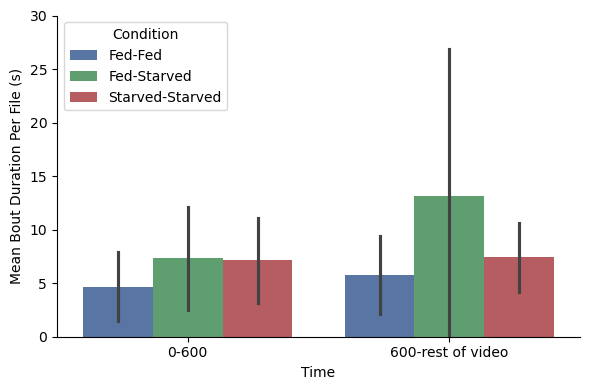

In [20]:
# Head-head bout duration split into 0-600 and rest of video, with Condition as hue.
head_head_hue_df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
head_head_hue_df1['Condition'] = 'Fed-Fed'

head_head_hue_df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
head_head_hue_df2['Condition'] = 'Fed-Starved'

head_head_hue_df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
head_head_hue_df3['Condition'] = 'Starved-Starved'

head_head_hue_df = pd.concat([head_head_hue_df1, head_head_hue_df2, head_head_hue_df3], ignore_index=True)
head_head_hue_df = head_head_hue_df[head_head_hue_df['initial_type'] == 'head_head'].copy()

head_head_hue_df['time_bin'] = np.where(
    head_head_hue_df['start_frame'] < 1200,
    '0-600',
    '600-rest of video',
)

duration_0_600_rest_hue = (
    head_head_hue_df.groupby(['Condition', 'file', 'time_bin'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=duration_0_600_rest_hue,
    x='time_bin',
    y='mean_bout_duration',
    hue='Condition',
    order=['0-600', '600-rest of video'],
    hue_order=order,
    palette=palette,
    errorbar='sd',
)

plt.xlabel('Time')
plt.ylabel('Mean Bout Duration Per File (s)')
plt.ylim(0, 30)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/mean-head-duration-0-600-600-end.pdf', format='pdf')
plt.show()


In [ ]:
# Simple Mann-Whitney tests for the plot above.
from scipy.stats import mannwhitneyu

results = []

def add_mann_whitney(test_type, group, comparison, values_1, values_2):
    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')
    results.append({
        'Test Type': test_type,
        'Group': group,
        'Comparison': comparison,
        'n 1': len(values_1),
        'n 2': len(values_2),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': '*' if p_value < 0.05 else '',
    })

# Within each condition: 0-600 vs rest of video.
for condition in order:
    condition_data = duration_0_600_rest_hue[duration_0_600_rest_hue['Condition'] == condition]

    values_0_600 = condition_data.loc[
        condition_data['time_bin'] == '0-600',
        'mean_bout_duration'
    ]
    values_rest = condition_data.loc[
        condition_data['time_bin'] == '600-rest of video',
        'mean_bout_duration'
    ]

    add_mann_whitney(
        'Within condition',
        condition,
        '0-600 vs 600-rest of video',
        values_0_600,
        values_rest,
    )

# Within each time bin: compare conditions.
comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

for time_bin in ['0-1200', '1200-rest of video']:
    time_data = duration_0_600_rest_hue[duration_0_600_rest_hue['time_bin'] == time_bin]

    for group_1, group_2 in comparisons:
        values_1 = time_data.loc[
            time_data['Condition'] == group_1,
            'mean_bout_duration'
        ]
        values_2 = time_data.loc[
            time_data['Condition'] == group_2,
            'mean_bout_duration'
        ]

        add_mann_whitney(
            'Within time bin',
            time_bin,
            f'{group_1} vs {group_2}',
            values_1,
            values_2,
        )

mann_whitney_0_600_rest_results = pd.DataFrame(results)
mann_whitney_0_600_rest_results


,Test Type,Group,Comparison,n 1,n 2,Mann-Whitney U,p value,sig
0,Within condition,Fed-Fed,0-600 vs 600-rest of video,8,14,48.5,0.631852,
1,Within condition,Fed-Starved,0-600 vs 600-rest of video,11,15,52.5,0.125305,
2,Within condition,Starved-Starved,0-600 vs 600-rest of video,8,5,17.5,0.769081,
3,Within time bin,0-600,Fed-Fed vs Fed-Starved,8,11,29.5,0.246221,
4,Within time bin,0-600,Fed-Starved vs Starved-Starved,11,8,44.5,1.000000,
5,Within time bin,600-rest of video,Fed-Fed vs Fed-Starved,14,15,48.5,0.014367,*
6,Within time bin,600-rest of video,Fed-Starved vs Starved-Starved,15,5,47.5,0.406622,
